Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Formal Exploratory Analysis: Correlation Matrix
Data loaded: 8,985 tracts

--- Correlation Matrix ---
                             total_population  total_housing_units  \
total_population                        1.000                0.872   
total_housing_units                     0.872                1.000   
median_household_income                 0.279                0.196   
median_home_value                       0.172                0.206   
housing_built_2010_or_later             0.723                0.718   
housing_built_before_2000               0.207                0.413   
turbine_count                          -0.090               -0.081   
has_wind_farm                          -0.118               -0.104   

                             median_household_income  median_home_value  \
total_population                               0.279          

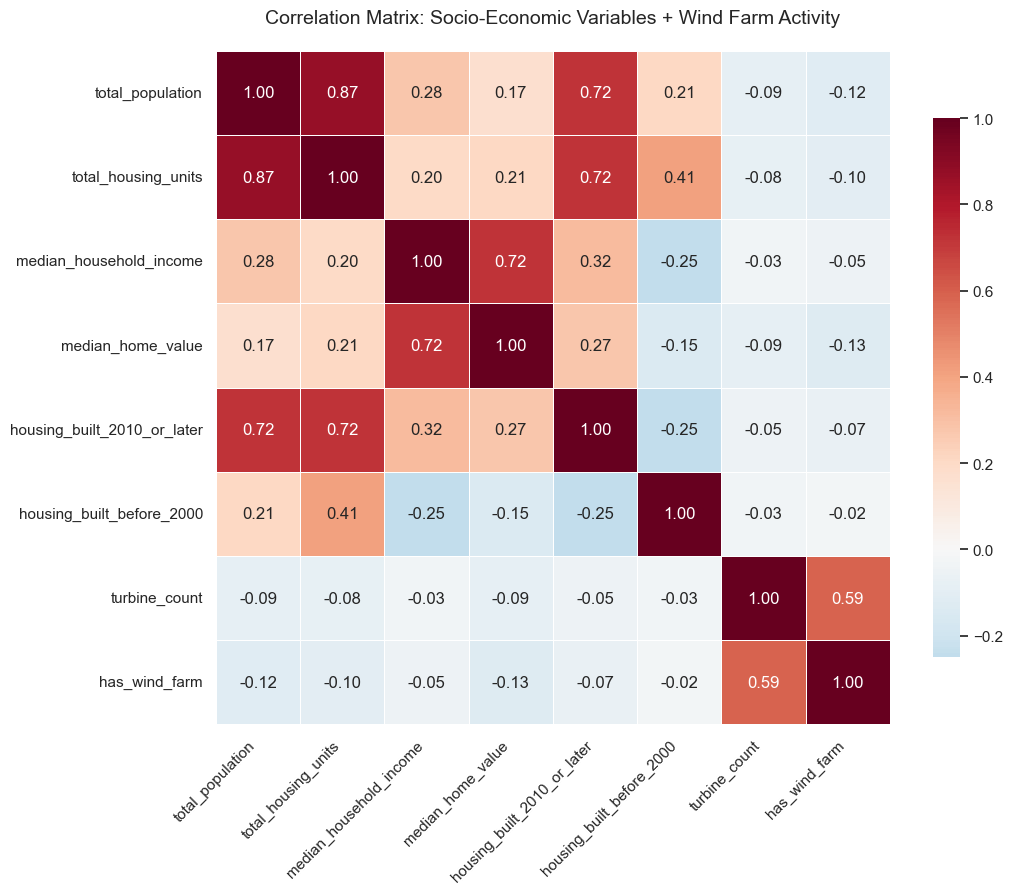


--- Correlations with has_wind_farm (sorted) ---
has_wind_farm                  1.000
turbine_count                  0.593
housing_built_before_2000     -0.024
median_household_income       -0.054
housing_built_2010_or_later   -0.070
total_housing_units           -0.104
total_population              -0.118
median_home_value             -0.127
Name: has_wind_farm, dtype: float64

--- Correlations with turbine_count (sorted) ---
turbine_count                  1.000
has_wind_farm                  0.593
housing_built_before_2000     -0.031
median_household_income       -0.035
housing_built_2010_or_later   -0.046
total_housing_units           -0.081
median_home_value             -0.085
total_population              -0.090
Name: turbine_count, dtype: float64

--- Group Means: With vs Without Wind Farms ---
has_wind_farm                       0         1
total_population               4220.5    2901.1
total_housing_units            1724.8    1307.0
median_household_income       79553.4   697

In [1]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 9)

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Formal Exploratory Analysis: Correlation Matrix")
print("=" * 70)

# Load data
df = pd.read_parquet(file_path)
print(f"Data loaded: {len(df):,} tracts")

# ============================================================
# 1. SELECT KEY NUMERIC VARIABLES
# ============================================================

# Choose the most relevant variables for analysis
numeric_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000",
    "turbine_count",
    "has_wind_farm"          # binary target
]

df_numeric = df[numeric_cols].copy()

# ============================================================
# 2. COMPUTE CORRELATION MATRIX
# ============================================================

corr_matrix = df_numeric.corr(method="pearson")

print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))

# ============================================================
# 3. VISUALIZE CORRELATION MATRIX (Heatmap)
# ============================================================

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix: Socio-Economic Variables + Wind Farm Activity", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 4. FOCUS: Correlations with Wind Farm Presence & Turbine Count
# ============================================================

print("\n--- Correlations with has_wind_farm (sorted) ---")
print(corr_matrix["has_wind_farm"].sort_values(ascending=False).round(3))

print("\n--- Correlations with turbine_count (sorted) ---")
print(corr_matrix["turbine_count"].sort_values(ascending=False).round(3))

# ============================================================
# 5. SIMPLE STATISTICAL COMPARISON (Group Means)
# ============================================================

print("\n--- Group Means: With vs Without Wind Farms ---")
group_means = df.groupby("has_wind_farm")[numeric_cols].mean().round(1)
print(group_means.T)

print("=" * 70)